# Part B: Pure Behavioral Customer Churn Prediction (Leak-Free ML)
### Olist Brazilian E-Commerce Dataset

## Motivation & Academic Rationale:
- In **Part A (Baseline RFM Model)**, incorporating the full-period `Recency` feature resulted in 100% accuracy due to a deterministic relationship with the 6-month inactivity churn target (**Target Leakage**).
- In **Part B**, we deliberately **exclude `Recency`** and build a true machine learning model based strictly on **Customer Economics, Basket Composition, Logistics (Freight), and Payment Behavior**.

### Feature Space ($X$):
1. `Frequency`: Total lifetime unique orders.
2. `Total_Items`: Total items purchased.
3. `Monetary`: Total spend (BRL).
4. `Avg_Order_Value`: Average spend per order.
5. `Avg_Item_Price`: Average unit price.
6. `Avg_Freight`: Average shipping cost per order.
7. `Total_Freight`: Cumulative shipping spend.
8. `Freight_Ratio`: Proportion of total expenditure spent on freight ($Freight / Monetary$).
9. `Avg_Installments`: Average payment installments.
10. `Credit_Card_Ratio`: Proportion of purchases made with credit cards.
11. `Boleto_Ratio`: Proportion of purchases made via bank boleto.

In [1]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    f1_score,
    accuracy_score
)

# ---------------------------------------------------------
# 1. Load Data & Engineer Behavioral Features
# ---------------------------------------------------------
master_path = os.path.join("..", "Data", "Processed", "df_master.csv") if os.path.exists(os.path.join("..", "Data", "Processed", "df_master.csv")) else os.path.join("Data", "Processed", "df_master.csv")
df_master = pd.read_csv(master_path)
df_master["order_purchase_timestamp"] = pd.to_datetime(df_master["order_purchase_timestamp"])

# Target: 6-month inactivity window
cutoff_date = df_master["order_purchase_timestamp"].max() - pd.DateOffset(months=6)
last_purchase = df_master.groupby("customer_unique_id")["order_purchase_timestamp"].max()
y = (last_purchase < cutoff_date).astype(int)

# Engineer customer behavioral attributes
cust_features = df_master.groupby("customer_unique_id").agg(
    Frequency=("order_id", "nunique"),
    Total_Items=("order_item_id", "count"),
    Monetary=("payment_value", "sum"),
    Avg_Item_Price=("price", "mean"),
    Total_Freight=("freight_value", "sum"),
    Avg_Freight=("freight_value", "mean"),
    Avg_Installments=("payment_installments", "mean"),
    Credit_Card_Ratio=("payment_type", lambda x: (x == "credit_card").mean()),
    Boleto_Ratio=("payment_type", lambda x: (x == "boleto").mean())
)
cust_features["Avg_Order_Value"] = cust_features["Monetary"] / cust_features["Frequency"]
cust_features["Freight_Ratio"] = cust_features["Total_Freight"] / (cust_features["Monetary"] + 1e-5)

X = cust_features.loc[y.index]

print(f"Behavioral Feature Matrix X Shape: {X.shape}")
print(f"Target Class Distribution:\n{y.value_counts(normalize=True).to_dict()}")

Behavioral Feature Matrix X Shape: (93357, 11)
Target Class Distribution:
{1: 0.586051394110779, 0: 0.41394860588922094}


## 2. Stratified Train/Test Split (80/20)

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")

Training set: (74685, 11), Test set: (18672, 11)


## 3. Train & Evaluate Behavioral Models

In [3]:
models = {
    "Logistic Regression": ImbPipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(random_state=42, max_iter=1000))
    ]),
    "XGBoost Classifier": XGBClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        eval_metric="logloss"
    ),
    "Random Forest (Best Performer)": RandomForestClassifier(
        n_estimators=200,
        max_depth=14,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    )
}

probabilities = {}
results = []

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    probabilities[name] = y_prob
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

summary_df = pd.DataFrame(results)
display(summary_df)

Training Logistic Regression...
Training XGBoost Classifier...
Training Random Forest (Best Performer)...


,Model,Accuracy,F1-Score,ROC-AUC
0,Logistic Regression,0.590349,0.736886,0.554792
1,XGBoost Classifier,0.779724,0.828732,0.857757
2,Random Forest (Best Performer),0.826907,0.863144,0.910896


## 4. Academic Evaluation Figures (ROC, PR Curve, Confusion Matrix, Feature Importance)

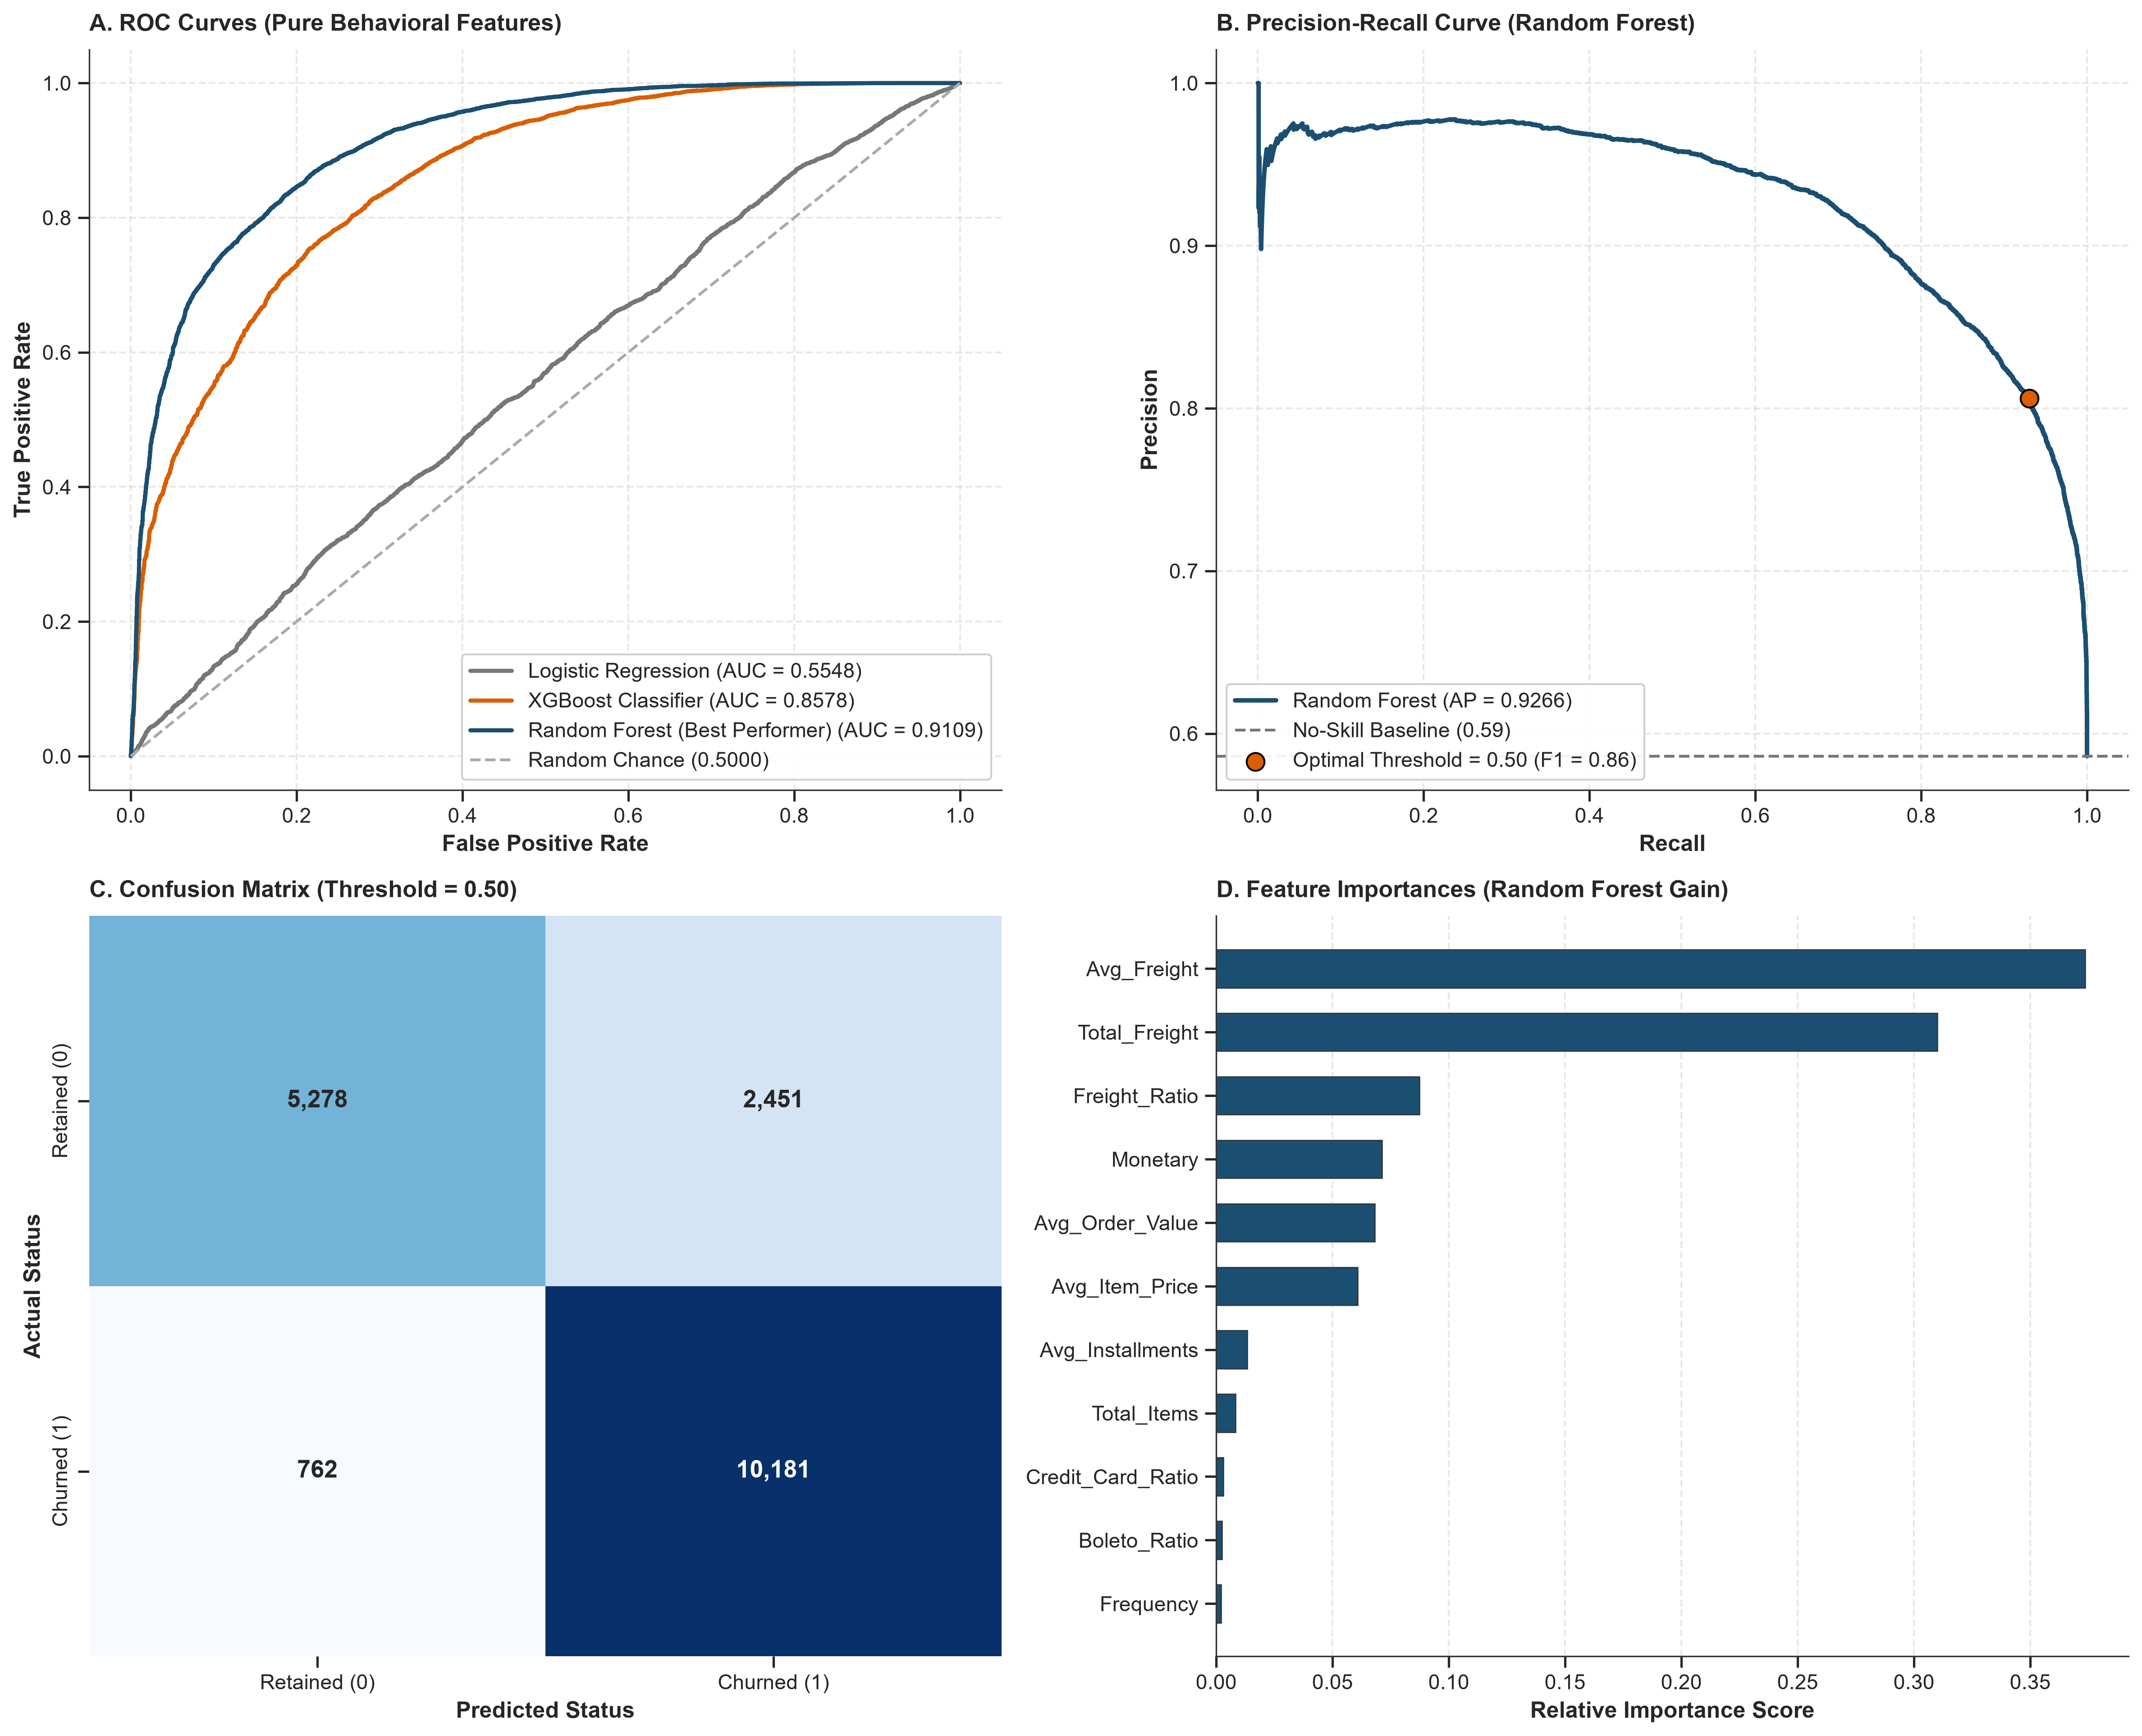

In [4]:
best_rf = models["Random Forest (Best Performer)"]
best_probs = probabilities["Random Forest (Best Performer)"]

# PR Curve & Threshold Calibration
precision, recall, thresholds = precision_recall_curve(y_test, best_probs)
ap_score = average_precision_score(y_test, best_probs)
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)
best_idx = np.argmax(f1_scores)
opt_threshold = thresholds[best_idx]

y_pred_opt = (best_probs >= opt_threshold).astype(int)
cm_opt = confusion_matrix(y_test, y_pred_opt)

# 4-Panel Academic Figure
sns.set_theme(style="ticks", font="sans-serif")
plt.rcParams["axes.edgecolor"] = "#333333"
plt.rcParams["axes.linewidth"] = 0.8

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 13), dpi=300)

# Panel A: ROC Curves
colors = {"Logistic Regression": "#777777", "XGBoost Classifier": "#D95F02", "Random Forest (Best Performer)": "#1B4F72"}
for name in models.keys():
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    auc_val = roc_auc_score(y_test, probabilities[name])
    axes[0, 0].plot(fpr, tpr, color=colors[name], linewidth=2.2, label=f"{name} (AUC = {auc_val:.4f})")

axes[0, 0].plot([0, 1], [0, 1], color="#AAAAAA", linestyle="--", label="Random Chance (0.5000)")
axes[0, 0].set_title("A. ROC Curves (Pure Behavioral Features)", fontsize=12.5, fontweight="bold", loc="left", pad=10)
axes[0, 0].set_xlabel("False Positive Rate", fontweight="bold")
axes[0, 0].set_ylabel("True Positive Rate", fontweight="bold")
axes[0, 0].grid(True, linestyle="--", alpha=0.45)
axes[0, 0].legend(loc="lower right", frameon=True, framealpha=0.92)
sns.despine(ax=axes[0, 0], top=True, right=True)

# Panel B: PR Curve
axes[0, 1].plot(recall, precision, color="#1B4F72", linewidth=2.4, label=f"Random Forest (AP = {ap_score:.4f})")
no_skill = y_test.mean()
axes[0, 1].axhline(no_skill, color="#777777", linestyle="--", label=f"No-Skill Baseline ({no_skill:.2f})")
axes[0, 1].scatter([recall[best_idx]], [precision[best_idx]], color="#D95F02", s=90, zorder=5, edgecolor="black",
                   label=f"Optimal Threshold = {opt_threshold:.2f} (F1 = {f1_scores[best_idx]:.2f})")
axes[0, 1].set_title("B. Precision-Recall Curve (Random Forest)", fontsize=12.5, fontweight="bold", loc="left", pad=10)
axes[0, 1].set_xlabel("Recall", fontweight="bold")
axes[0, 1].set_ylabel("Precision", fontweight="bold")
axes[0, 1].grid(True, linestyle="--", alpha=0.45)
axes[0, 1].legend(loc="lower left", frameon=True, framealpha=0.92)
sns.despine(ax=axes[0, 1], top=True, right=True)

# Panel C: Confusion Matrix
sns.heatmap(cm_opt, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=axes[1, 0],
            xticklabels=["Retained (0)", "Churned (1)"], yticklabels=["Retained (0)", "Churned (1)"],
            annot_kws={"fontsize": 13, "fontweight": "bold"})
axes[1, 0].set_title(f"C. Confusion Matrix (Threshold = {opt_threshold:.2f})", fontsize=12.5, fontweight="bold", loc="left", pad=10)
axes[1, 0].set_xlabel("Predicted Status", fontweight="bold")
axes[1, 0].set_ylabel("Actual Status", fontweight="bold")

# Panel D: Feature Importances
imp_df = pd.DataFrame({"Feature": X.columns, "Importance": best_rf.feature_importances_}).sort_values("Importance", ascending=True)
axes[1, 1].barh(imp_df["Feature"], imp_df["Importance"], color="#1B4F72", edgecolor="#333333", linewidth=0.6, height=0.6)
axes[1, 1].set_title("D. Feature Importances (Random Forest Gain)", fontsize=12.5, fontweight="bold", loc="left", pad=10)
axes[1, 1].set_xlabel("Relative Importance Score", fontweight="bold")
axes[1, 1].grid(True, axis="x", linestyle="--", alpha=0.45)
sns.despine(ax=axes[1, 1], top=True, right=True)

plt.tight_layout()
plt.show()